### Homework 7 CELL DNA

In [46]:
# Import data and library

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


df = pd.read_csv("ML_HW_Data_CellDNA.csv", header=None)

In [47]:
# split features (X) and Target (y)
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Step 2: preprocess the data
y_binary = np.where(y > 0, 1, 0)

# feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Model initialization and training
model = SVC(kernel='linear', probability=True, random_state=42)
model.fit(X_scaled, y_binary)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [48]:
# Question 1

# n_support_ returns an array with the number of support vectors for each class
sv_per_class = model.n_support_
total_sv = np.sum(sv_per_class)

print(f"support Vectors for Class 0: {sv_per_class[0]}")
print(f"support Vectors for Class 1: {sv_per_class[1]}")
print(f"Total Support Vectors found: {total_sv}")

support Vectors for Class 0: 115
support Vectors for Class 1: 113
Total Support Vectors found: 228


In [49]:
# Extract the raw decision values
decision_values = model.decision_function(X_scaled)
abs_decision_values = np.abs(decision_values)

# question 2

# take the first 3 indices for the smallest absolute values
top_3_indices = np.argsort(abs_decision_values)[:3]

print("--- Question 2: Top 3 Records with smallest ABS ---")
for idx in top_3_indices:
    print(f"Record Index (Python): {idx} | Absolute Value: {abs_decision_values[idx]:.6f} | Raw Value: {decision_values[idx]:.6f}")

--- Question 2: Top 3 Records with smallest ABS ---
Record Index (Python): 780 | Absolute Value: 0.003266 | Raw Value: -0.003266
Record Index (Python): 462 | Absolute Value: 0.004384 | Raw Value: -0.004384
Record Index (Python): 339 | Absolute Value: 0.005284 | Raw Value: -0.005284


In [50]:
# question 3

records_of_interest = [130, 164, 891, 1056]
print("--- Q3: Record Analysis ---")

# extract the calc probabilities
probabilities = model.predict_proba(X_scaled)

for rec_idx in records_of_interest:
    dec_val = decision_values[rec_idx]
    prob_class_1 = probabilities[rec_idx][1] 
    
    print(f"Record {rec_idx}:")
    
    print(f"  Decision Value: {dec_val:.6f}")

    print(f"  Probability of Class 1: {prob_class_1:.6f}")

--- Q3: Record Analysis ---
Record 130:
  Decision Value: -21.177568
  Probability of Class 1: 0.000000
Record 164:
  Decision Value: 9.342155
  Probability of Class 1: 1.000000
Record 891:
  Decision Value: 4.584146
  Probability of Class 1: 0.999998
Record 1056:
  Decision Value: -26.296517
  Probability of Class 1: 0.000000


In [51]:
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Question 4 - precision, recall, f measure

y_pred = model.predict(X_scaled)

print("--- Question 4: Classification Quality Metrics ---")

print(classification_report(y_binary, y_pred, digits=4))


--- Question 4: Classification Quality Metrics ---
              precision    recall  f1-score   support

           0     0.9439    0.9587    0.9512      1017
           1     0.7717    0.7100    0.7396       200

    accuracy                         0.9178      1217
   macro avg     0.8578    0.8344    0.8454      1217
weighted avg     0.9156    0.9178    0.9164      1217



In [52]:
# Q5 ROC Curve and AUC

prob_class_0 = probabilities[:, 0]
prob_class_1 = probabilities[:, 1]

# 1. Calculate ROC metrics for Class 1
fpr_1, tpr_1, _ = roc_curve(y_binary, prob_class_1)
roc_auc_1 = auc(fpr_1, tpr_1)

# 2. Calculate ROC metrics for Class 0 

y_binary_class_0 = np.where(y_binary == 0, 1, 0)
fpr_0, tpr_0, _ = roc_curve(y_binary_class_0, prob_class_0)
roc_auc_0 = auc(fpr_0, tpr_0)

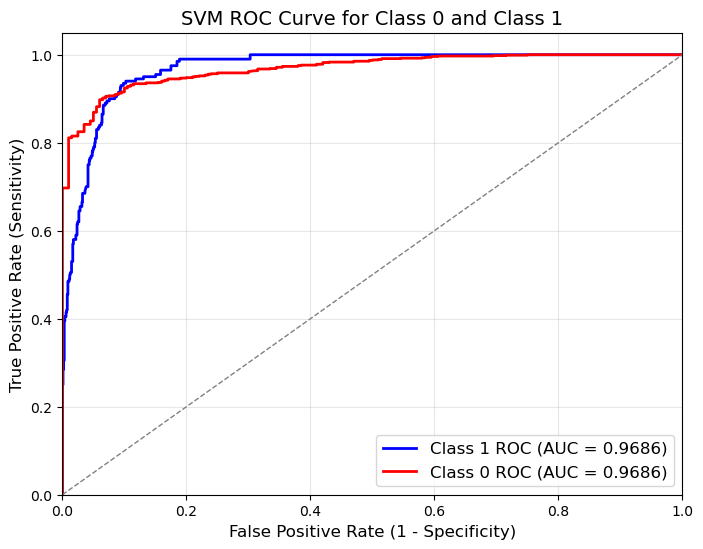

In [53]:
# Plotting the ROC Curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_1, tpr_1, color='blue', lw=2, label=f'Class 1 ROC (AUC = {roc_auc_1:.4f})')
plt.plot(fpr_0, tpr_0, color='red', lw=2, label=f'Class 0 ROC (AUC = {roc_auc_0:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('SVM ROC Curve for Class 0 and Class 1', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

plt.savefig('ROC_Curve_Q5.png', bbox_inches='tight')

In [54]:
print("\n Question 5: ROC Analysis ")
print(f"AUC for Class 0: {roc_auc_0:.4f}")
print(f"AUC for Class 1: {roc_auc_1:.4f}")


 Question 5: ROC Analysis 
AUC for Class 0: 0.9686
AUC for Class 1: 0.9686
